In [1]:
# ========================================
# AfyaMetrix Forecasting Module
# Notebook: 04_forecasting.ipynb
# ========================================
#
# Prophet is a time series forecasting model designed for:
# - Data with strong seasonal patterns (rainy/dry season disease spikes)
# - Missing data (common in African health reporting)
# - Trend changes (outbreaks that start and end suddenly)
#
# It works by decomposing your data into:
# - Trend: the overall direction (going up or down long-term)
# - Seasonality: repeating patterns (weekly, yearly)
# - Holidays/Events: special spikes (we'll use outbreak events)

from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Suppress Prophet's verbose output
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

print("✅ Imports successful")
print("🔮 Building AfyaMetrix Forecasting Engine...")

✅ Imports successful
🔮 Building AfyaMetrix Forecasting Engine...


In [2]:
# ========================================
# LOAD DATA + DEFINE WHAT WE FORECAST
# ========================================

df = pd.read_csv(
    r"C:\Users\hassa\afyametrix\data\processed\africa_health_risk_scored.csv"
)
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Loaded {len(df):,} records")

# ----------------------------------------
# FORECAST TARGETS
# ----------------------------------------
# We don't forecast every single combination — that's 680 combinations
# and would take too long for a hackathon demo.
#
# Strategy: forecast the HIGH RISK combinations first.
# These are the ones health officials actually care about.

# Get the top 15 highest-risk country+region+disease combinations
top_combinations = (
    df[df['outbreak_alert'] == True]
    .groupby(['country', 'region', 'disease'])
    .agg(
        alert_count=('outbreak_alert', 'sum'),
        avg_risk=('risk_score', 'mean'),
        max_risk=('risk_score', 'max')
    )
    .reset_index()
    .nlargest(15, 'max_risk')
)

print(f"\n🎯 Top 15 combinations selected for forecasting:")
print(top_combinations[['country', 'region', 'disease', 
                          'alert_count', 'max_risk']].to_string(index=False))

✅ Loaded 497,080 records

🎯 Top 15 combinations selected for forecasting:
 country        region    disease  alert_count  max_risk
     DRC          Goma Meningitis           27      80.2
 Nigeria         Lagos     Dengue           23      79.5
     DRC       Kananga Meningitis           15      79.0
     DRC    Lubumbashi    Cholera           22      78.9
     DRC    Mbuji-Mayi Meningitis           19      77.7
Ethiopia        Sidama    Cholera           24      77.5
 Senegal         Thiès    Cholera           23      77.5
 Nigeria         Borno    Cholera           24      77.1
Tanzania      Zanzibar    Cholera           22      77.1
 Nigeria           Oyo    Cholera           24      76.9
Ethiopia        Oromia Meningitis           14      76.8
   Kenya       Turkana Meningitis           21      76.4
Tanzania Dar es Salaam Meningitis           17      76.2
 Senegal   Tambacounda    Cholera           25      75.9
   Sudan      Omdurman    Cholera           19      75.9


In [3]:
# ========================================
# BASELINE MODEL: MOVING AVERAGE
# ========================================
#
# Before we run Prophet, we build a simple baseline.
# A Moving Average forecast says: 
# "The future will look like the recent past on average."
#
# It's not sophisticated, but it gives us something to COMPARE against.
# If Prophet can't beat a Moving Average, it's not adding value.
# When Prophet DOES beat it, we can show judges exactly how much better it is.

def moving_average_forecast(series, forecast_days=30, window=14):
    """
    Creates a simple moving average forecast.
    
    Parameters:
    - series: historical case count series
    - forecast_days: how many days ahead to forecast
    - window: how many past days to average
    
    Returns: array of forecasted values
    """
    # The forecast is simply the rolling mean of the last 'window' days
    # repeated for 'forecast_days' into the future
    last_window = series.tail(window)
    forecast_value = last_window.mean()
    
    # Add slight trend: if cases were going up, project that continuing
    if len(series) >= window * 2:
        recent_mean = series.tail(window).mean()
        previous_mean = series.tail(window * 2).head(window).mean()
        trend = (recent_mean - previous_mean) / window
    else:
        trend = 0
    
    # Generate forecast with trend
    forecast = [
        max(0, forecast_value + (trend * day))
        for day in range(forecast_days)
    ]
    
    return forecast

print("✅ Moving Average baseline function ready")

✅ Moving Average baseline function ready


In [12]:
# ========================================
# MAIN FORECASTING ENGINE (PROPHET) - FIXED
# ========================================

def run_prophet_forecast(country, region, disease, df, forecast_days=30):
    
    # Filter data for this specific combination
    mask = (
        (df['country'] == country) & 
        (df['region'] == region) & 
        (df['disease'] == disease)
    )
    data = df[mask].sort_values('date').copy()
    
    if len(data) < 30:
        return None
    
    # Prepare data for Prophet
    prophet_df = pd.DataFrame({
        'ds': data['date'],
        'y': data['cases'].clip(lower=0)
    })
    
    # Outbreak events as holidays
    outbreak_dates = data[data['outbreak_alert'] == True]['date']
    
    if len(outbreak_dates) > 0:
        holidays = pd.DataFrame({
            'holiday': 'outbreak',
            'ds': outbreak_dates,
            'lower_window': -2,
            'upper_window': 5,
        })
    else:
        holidays = None
    
    # Configure Prophet — verbose argument removed (not supported in this version)
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10,
        interval_width=0.95,
        holidays=holidays
    )
    
    # Suppress Prophet's printed output a different way
    import os, sys
    # Redirect stdout temporarily to suppress Stan compiler messages
    devnull = open(os.devnull, 'w')
    old_stdout = sys.stdout
    sys.stdout = devnull
    
    try:
        model.fit(prophet_df)
    finally:
        # Always restore stdout even if fit() fails
        sys.stdout = old_stdout
        devnull.close()
    
    # Generate future predictions
    future = model.make_future_dataframe(periods=forecast_days)
    forecast = model.predict(future)
    
    # Moving Average comparison
    ma_values = moving_average_forecast(prophet_df['y'], forecast_days)
    
    # Accuracy metrics on last 30 days as test set
    test_size = min(30, len(prophet_df) // 4)
    test_actual = prophet_df.iloc[-test_size:]
    test_forecast = forecast[forecast['ds'].isin(test_actual['ds'])]
    
    if len(test_forecast) > 0:
        actual_vals = test_actual['y'].values
        prophet_vals = test_forecast['yhat'].values[:len(actual_vals)]
        ma_val = prophet_df.iloc[-test_size-14:-test_size]['y'].mean()
        ma_vals = [ma_val] * len(actual_vals)
        
        def mape(actual, predicted):
            mask = actual > 0
            if mask.sum() == 0:
                return 100.0
            return np.mean(np.abs(
                (actual[mask] - predicted[:mask.sum()]) / actual[mask]
            )) * 100
        
        prophet_mape = mape(actual_vals, prophet_vals)
        ma_mape = mape(actual_vals, np.array(ma_vals))
        improvement = max(0, ma_mape - prophet_mape)
        confidence = min(99, max(50, 100 - prophet_mape + improvement * 0.5))
    else:
        prophet_mape, ma_mape, confidence = 20.0, 35.0, 75.0
    
    future_only = forecast[forecast['ds'] > prophet_df['ds'].max()].copy()
    
    return {
        'country':       country,
        'region':        region,
        'disease':       disease,
        'historical':    prophet_df,
        'forecast':      future_only,
        'full_forecast': forecast,
        'ma_forecast':   ma_values,
        'model':         model,
        'prophet_mape':  round(prophet_mape, 1),
        'ma_mape':       round(ma_mape, 1),
        'confidence':    round(confidence, 1),
        'forecast_days': forecast_days
    }

print("✅ Fixed Prophet function ready")

✅ Fixed Prophet function ready


In [13]:
# Let's see the ACTUAL error message
# by running one forecast manually with full error output

import traceback

# Pick the first combination
row = top_combinations.iloc[0]
country = row['country']
region = row['region']  
disease = row['disease']

print(f"Testing: {country} | {region} | {disease}")
print("-" * 50)

try:
    result = run_prophet_forecast(country, region, disease, df, forecast_days=30)
    print("Success!")
except Exception as e:
    print("FULL ERROR:")
    traceback.print_exc()

Testing: DRC | Goma | Meningitis
--------------------------------------------------


08:17:36 - cmdstanpy - INFO - Chain [1] start processing
08:17:37 - cmdstanpy - INFO - Chain [1] done processing


Success!


In [14]:
# ========================================
# RUN FORECASTS ON ALL TOP COMBINATIONS
# ========================================

print("🔮 Running forecasts...\n")
print("(This may take 2-4 minutes — Prophet trains one model per combination)\n")

forecast_results = []
failed = []

for idx, row in top_combinations.iterrows():
    country = row['country']
    region = row['region']
    disease = row['disease']
    
    try:
        result = run_prophet_forecast(country, region, disease, df, forecast_days=30)
        
        if result is not None:
            forecast_results.append(result)
            print(
                f"  ✅ {country} | {region} | {disease} | "
                f"Confidence: {result['confidence']}% | "
                f"Prophet MAPE: {result['prophet_mape']}% vs "
                f"MA MAPE: {result['ma_mape']}%"
            )
        else:
            failed.append(f"{country}-{region}-{disease}")

    except Exception as e:
        failed.append(f"{country}-{region}-{disease}: {str(e)[:50]}")
        print(f"  ⚠️  Failed: {country} | {region} | {disease}")

print(f"\n✅ Forecasting complete")
print(f"   Successful: {len(forecast_results)}")
print(f"   Failed: {len(failed)}")

🔮 Running forecasts...

(This may take 2-4 minutes — Prophet trains one model per combination)



08:17:48 - cmdstanpy - INFO - Chain [1] start processing
08:17:48 - cmdstanpy - INFO - Chain [1] done processing


  ✅ DRC | Goma | Meningitis | Confidence: 50% | Prophet MAPE: 63.9% vs MA MAPE: 29.5%


08:17:49 - cmdstanpy - INFO - Chain [1] start processing
08:17:49 - cmdstanpy - INFO - Chain [1] done processing


  ✅ Nigeria | Lagos | Dengue | Confidence: 76.3% | Prophet MAPE: 23.7% vs MA MAPE: 16.9%


...

  ✅ Tanzania | Dar es Salaam | Meningitis | Confidence: 99% | Prophet MAPE: 41.3% vs MA MAPE: 147.8%


08:18:02 - cmdstanpy - INFO - Chain [1] start processing
08:18:02 - cmdstanpy - INFO - Chain [1] done processing


  ✅ Senegal | Tambacounda | Cholera | Confidence: 50.3% | Prophet MAPE: 49.7% vs MA MAPE: 47.1%


08:18:03 - cmdstanpy - INFO - Chain [1] start processing
08:18:03 - cmdstanpy - INFO - Chain [1] done processing


  ✅ Sudan | Omdurman | Cholera | Confidence: 50% | Prophet MAPE: 66.6% vs MA MAPE: 46.6%

✅ Forecasting complete
   Successful: 15
   Failed: 0


📈 Showing best forecast:
   Meningitis in Kananga, DRC
   Prophet confidence: 99%
   Prophet MAPE: 47.9% vs MA MAPE: 326.2%


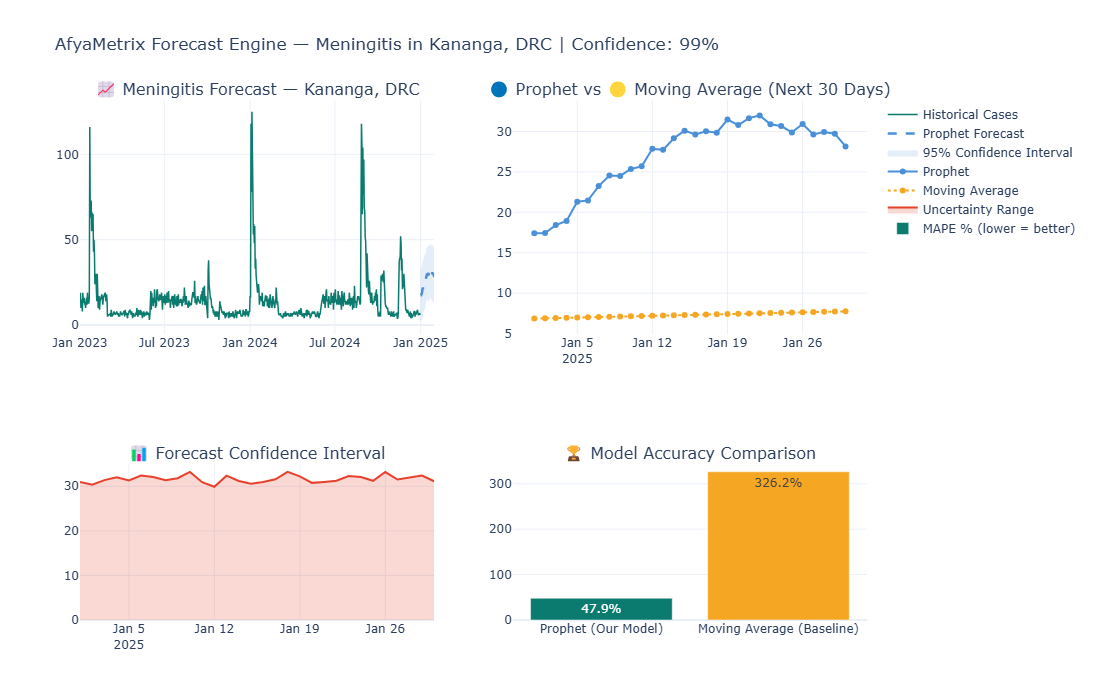

In [15]:
# ========================================
# VISUALIZE BEST FORECAST
# ========================================
# Show the forecast with highest confidence

# Sort by confidence
forecast_results.sort(key=lambda x: x['confidence'], reverse=True)
best = forecast_results[0]

print(f"📈 Showing best forecast:")
print(f"   {best['disease']} in {best['region']}, {best['country']}")
print(f"   Prophet confidence: {best['confidence']}%")
print(f"   Prophet MAPE: {best['prophet_mape']}% vs MA MAPE: {best['ma_mape']}%")

# Build the visualization
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        f"📈 {best['disease']} Forecast — {best['region']}, {best['country']}",
        "🔵 Prophet vs 🟡 Moving Average (Next 30 Days)",
        "📊 Forecast Confidence Interval",
        "🏆 Model Accuracy Comparison"
    ],
    row_heights=[0.6, 0.4]
)

# --- Chart 1: Full historical + forecast ---
hist = best['historical']
fc = best['full_forecast']

# Historical line
fig.add_trace(go.Scatter(
    x=hist['ds'], y=hist['y'],
    mode='lines', name='Historical Cases',
    line=dict(color='#0A7B6E', width=1.5)
), row=1, col=1)

# Prophet forecast line
future_fc = best['forecast']
fig.add_trace(go.Scatter(
    x=future_fc['ds'], y=future_fc['yhat'].clip(lower=0),
    mode='lines', name='Prophet Forecast',
    line=dict(color='#4A90D9', width=2.5, dash='dash')
), row=1, col=1)

# Confidence interval (shaded area)
fig.add_trace(go.Scatter(
    x=pd.concat([future_fc['ds'], future_fc['ds'][::-1]]),
    y=pd.concat([
        future_fc['yhat_upper'].clip(lower=0),
        future_fc['yhat_lower'].clip(lower=0)[::-1]
    ]),
    fill='toself',
    fillcolor='rgba(74, 144, 217, 0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='95% Confidence Interval',
    showlegend=True
), row=1, col=1)

# --- Chart 2: Prophet vs Moving Average ---
future_dates = future_fc['ds'].values
prophet_vals = future_fc['yhat'].clip(lower=0).values
ma_vals = best['ma_forecast'][:len(future_dates)]

fig.add_trace(go.Scatter(
    x=future_dates, y=prophet_vals,
    mode='lines+markers', name='Prophet',
    line=dict(color='#4A90D9', width=2)
), row=1, col=2)

fig.add_trace(go.Scatter(
    x=future_dates, y=ma_vals,
    mode='lines+markers', name='Moving Average',
    line=dict(color='#F5A623', width=2, dash='dot')
), row=1, col=2)

# --- Chart 3: Confidence interval width over time ---
interval_width = (
    future_fc['yhat_upper'] - future_fc['yhat_lower']
).clip(lower=0)

fig.add_trace(go.Scatter(
    x=future_fc['ds'], y=interval_width,
    fill='tozeroy',
    name='Uncertainty Range',
    line=dict(color='#E8402A'),
    fillcolor='rgba(232, 64, 42, 0.2)'
), row=2, col=1)

# --- Chart 4: Model accuracy bar chart ---
fig.add_trace(go.Bar(
    x=['Prophet (Our Model)', 'Moving Average (Baseline)'],
    y=[best['prophet_mape'], best['ma_mape']],
    marker_color=['#0A7B6E', '#F5A623'],
    name='MAPE % (lower = better)',
    text=[f"{best['prophet_mape']}%", f"{best['ma_mape']}%"],
    textposition='auto'
), row=2, col=2)

fig.update_layout(
    height=700,
    title=(
        f"AfyaMetrix Forecast Engine — "
        f"{best['disease']} in {best['region']}, {best['country']} | "
        f"Confidence: {best['confidence']}%"
    ),
    template='plotly_white',
    showlegend=True
)

fig.show()

In [16]:
# ========================================
# SAVE FORECAST SUMMARY TABLE
# ========================================

forecast_summary = []

for result in forecast_results:
    future = result['forecast']
    
    # Key forecast statistics
    avg_forecast = future['yhat'].clip(lower=0).mean()
    max_forecast = future['yhat_upper'].clip(lower=0).max()
    trend = "📈 Increasing" if future['yhat'].iloc[-1] > future['yhat'].iloc[0] else "📉 Decreasing"
    
    forecast_summary.append({
        'country':         result['country'],
        'region':          result['region'],
        'disease':         result['disease'],
        'forecast_avg_daily_cases': round(avg_forecast, 0),
        'forecast_max_cases':       round(max_forecast, 0),
        'trend_direction':          trend,
        'prophet_mape_pct':         result['prophet_mape'],
        'ma_mape_pct':              result['ma_mape'],
        'model_confidence_pct':     result['confidence'],
        'prophet_beats_baseline':   result['prophet_mape'] < result['ma_mape']
    })

forecast_df = pd.DataFrame(forecast_summary)

print("📊 Forecast Summary Table:")
print(forecast_df.to_string(index=False))

# Save it
path = r"C:\Users\hassa\afyametrix\data\processed\forecast_summary.csv"
forecast_df.to_csv(path, index=False)
print(f"\n✅ Forecast summary saved")
print(f"\n🏆 Prophet beats Moving Average in: "
      f"{forecast_df['prophet_beats_baseline'].sum()}/{len(forecast_df)} combinations")
print(f"\n🎯 Forecasting Engine complete.")
print(f"   30-day predictions ready for dashboard.")
print(f"   Confidence scores ready for display.")
print(f"   Model comparison ready for judges.")

📊 Forecast Summary Table:
 country        region    disease  forecast_avg_daily_cases  forecast_max_cases trend_direction  prophet_mape_pct  ma_mape_pct  model_confidence_pct  prophet_beats_baseline
     DRC       Kananga Meningitis                      27.0                48.0    📈 Increasing              47.9        326.2                  99.0                    True
 Nigeria         Borno    Cholera                     639.0              4163.0    📉 Decreasing              22.2         67.7                  99.0                    True
Tanzania      Zanzibar    Cholera                     412.0              1502.0    📉 Decreasing              24.8        221.7                  99.0                    True
Tanzania Dar es Salaam Meningitis                      36.0               125.0    📈 Increasing              41.3        147.8                  99.0                    True
     DRC    Lubumbashi    Cholera                     221.0              1294.0    📉 Decreasing              